In [1]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# CELL 2: Load Data
print("=" * 60)
print("LOADING DATASET")
print("=" * 60)

df = pd.read_csv("../data/raw/Churn_Modelling.csv")
print(f"✅ Dataset loaded: {df.shape}")
df.head()





LOADING DATASET
✅ Dataset loaded: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Display basic info
print("\n📊 Dataset Info:")
print(f"  • Total samples: {df.shape[0]:,}")
print(f"  • Total features: {df.shape[1]}")
print(f"  • Target distribution:")
print(df['Exited'].value_counts(normalize=True).mul(100).round(1)
      .to_string())


📊 Dataset Info:
  • Total samples: 10,000
  • Total features: 14
  • Target distribution:
Exited
0    79.6
1    20.4


In [4]:
print("\n Dataset Info:\n")
print(df.info())




 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [5]:
print("\nSummary statistics (numerical):")
df.describe().transpose()


Summary statistics (numerical):


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [6]:
# CELL 3: Drop Unnecessary Columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print(f"\n✅ Dropped unnecessary columns. New shape: {df.shape}")



✅ Dropped unnecessary columns. New shape: (10000, 11)


In [7]:
# CELL 4: Preprocessing
print("\n" + "=" * 60)
print("Preprocessing")
print("=" * 60)

# Check for missing values
print("\n Missing Values:\n")
print(df.isna().sum())


Preprocessing

 Missing Values:

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
#Check for duplicate

duplicate_rows=df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [9]:
# numerical Columns
num_cols=df.select_dtypes(include=['int64','float64']).columns
num_cols.tolist()


['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [10]:
# Categorical Columns
cat_cols=df.select_dtypes(include=['object']).columns
cat_cols.tolist()

['Geography', 'Gender']

In [11]:
# Check for wrong values
print(f"\nUnique values in categorical columns:")
print(f"Geography: {df['Geography'].unique()}")
print(f"Gender: {df['Gender'].unique()}")
print(f"NumOfProducts: {sorted(df['NumOfProducts'].unique())}")


Unique values in categorical columns:
Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
NumOfProducts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [12]:
# Check for impossible values
print(f"\nValue Ranges:")
print(f"Age: {df['Age'].min()} to {df['Age'].max()}")
print(f"CreditScore: {df['CreditScore'].min()} to {df['CreditScore'].max()}")
print(f"Balance: {df['Balance'].min()} to {df['Balance'].max()}")


Value Ranges:
Age: 18 to 92
CreditScore: 350 to 850
Balance: 0.0 to 250898.09


Key Findings:
Clean Data: The dataset has no missing values, so we can analyze it without any data gaps.

No wrong values in categorical columns

Geography: France, Spain, Germany (3 countries)

Gender: Male, Female (properly encoded)

NumOfProducts: 1-4 products per customer

All values within reasonable ranges

Removing Unnecessary Columns: We are dropping the columns 'RowNumber', 'CustomerId', and 'Surname' from the dataset as they uniquely identify each customer and do not provide any relevant information for building the customer churn model. Removing these columns allows us to focus on the meaningful features that contribute to predicting churn and improve the efficiency of our analysis.

Target Variable: The column “Exited” is our main focus, as it tells us whether a customer has churned or not. This will be used to train the prediction model.

In [13]:
outlier_summary = {}
outlier_col=num_cols.drop('Exited')
for col in outlier_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(outliers)
    }

pd.DataFrame(outlier_summary).T

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15.0
Age,32.00,44.0000,12.0000,14.00000,62.00000,359.0
Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0.0
Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0.0
NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60.0
HasCrCard,0.00,1.0000,1.0000,-1.50000,2.50000,0.0
IsActiveMember,0.00,1.0000,1.0000,-1.50000,2.50000,0.0
EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0.0


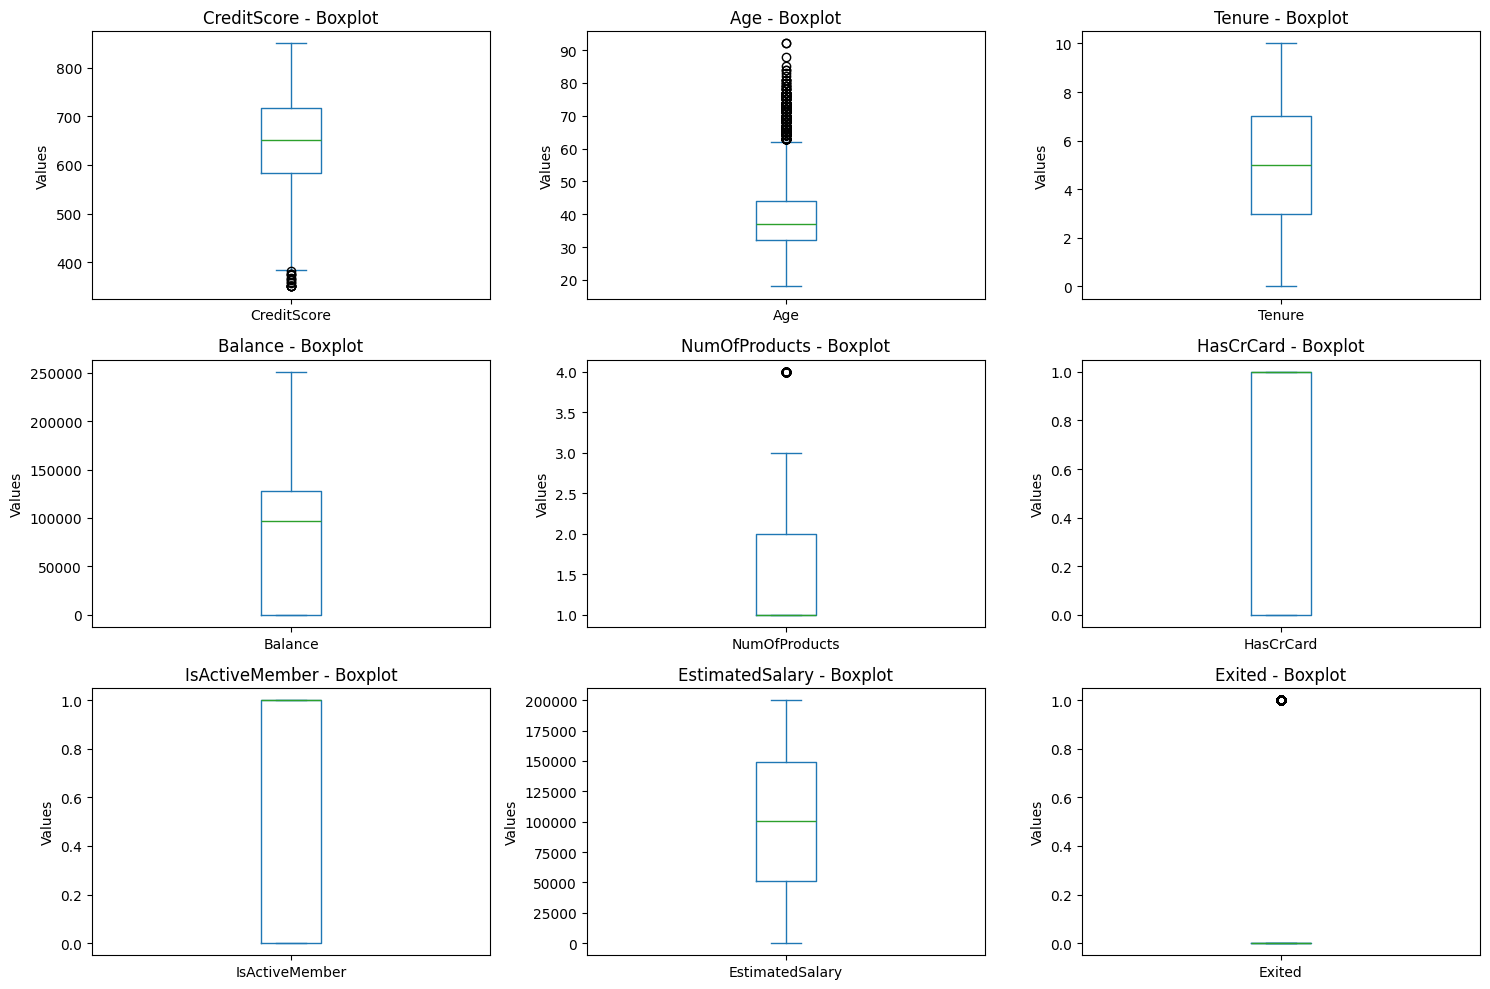

In [14]:
# Visualize outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    df[col].plot(kind='box', ax=axes[i], title=f'{col} - Boxplot')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()

In [15]:
Key Findings:
Outlier detection was performed using the Interquartile Range (IQR) method. The IQR method mathematically identifies values that fall below:

Lower Bound = Q1 – 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Here we do not remove or cap any outliers, for the reasons explained below:

Outlier analysis was performed using the IQR method. Although some features such as CreditScore, Age, and NumOfProducts showed statistical outliers, these values were retained because they represent genuine customer behavior rather than data errors.

In a banking dataset, high-value customers, older customers, and low/high credit score customers are crucial segments that significantly influence churn behavior. Removing or capping these values would lead to loss of meaningful information, distort model learning, and reduce real-world applicability.

Therefore, no outliers were removed, as all identified extreme values are valid business observations and important for accurate churn prediction.

SyntaxError: invalid character '–' (U+2013) (468690761.py, line 4)

In [15]:
# CELL 4: Feature Engineering
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Ratio features
df['BalanceSalaryRatio'] = (df['Balance'] / (df['EstimatedSalary'] + 1)).round(3)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)
df['ProductUtilizationRate'] = (df['NumOfProducts'] / (df['Tenure'] + 1)).round(3)

# Interaction features
df['AgeBalanceInteraction'] = df['Age'] * df['Balance']

# Engagement Score
df['EngagementScore'] = (
    df['IsActiveMember'] +
    df['HasCrCard'] +
    (df['NumOfProducts'] / df['NumOfProducts'].max())
).round(2)

# Credit Score Categories
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], 
                                   bins=[0, 580, 670, 740, 800, 850], 
                                   labels=[0, 1, 2, 3, 4],
                                   include_lowest=True).astype(int)

# After creating CreditScoreCategory, drop the original CreditScore
df = df.drop('CreditScore', axis=1)
print(f"✅ Dropped CreditScore. New columns: {df.columns.tolist()}")

# Simulated Complaint Count
np.random.seed(42)
df['ComplaintCount'] = np.random.poisson(lam=0.5, size=len(df))

print(f"✅ Feature engineering complete. New shape: {df.shape}")
df.head()



FEATURE ENGINEERING
✅ Dropped CreditScore. New columns: ['Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'BalanceSalaryRatio', 'TenureAgeRatio', 'ProductUtilizationRate', 'AgeBalanceInteraction', 'EngagementScore', 'CreditScoreCategory']
✅ Feature engineering complete. New shape: (10000, 17)


,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureAgeRatio,ProductUtilizationRate,AgeBalanceInteraction,EngagementScore,CreditScoreCategory,ComplaintCount
0,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000,0.046512,0.333,0.00,2.25,1,0
1,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.745,0.023810,0.500,3436122.26,1.25,1,2
2,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401,0.186047,0.333,6705753.60,1.75,0,0
3,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000,0.025000,1.000,0.00,0.50,2,0
4,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587,0.045455,0.333,5396965.26,2.25,4,0



CREATING LSTM SEQUENCE DATA
✅ LSTM sequences created: (10000, 6)

VALIDATING SYNTHETIC SEQUENCES

📊 Statistical Analysis of Generated Sequences:
   Mean balance: $76,710.62
   Std deviation: $62,569.27
   Min balance: $0.00
   Max balance: $250,998.09

📈 Volatility Analysis:
   Expected volatility (banking norm): 20.00%
   Your sequences volatility: 81.56%
   ⚠️ Adjustment needed: Volatility outside typical range

✅ No negative balances found (good)

📊 Generating sample sequence plots...


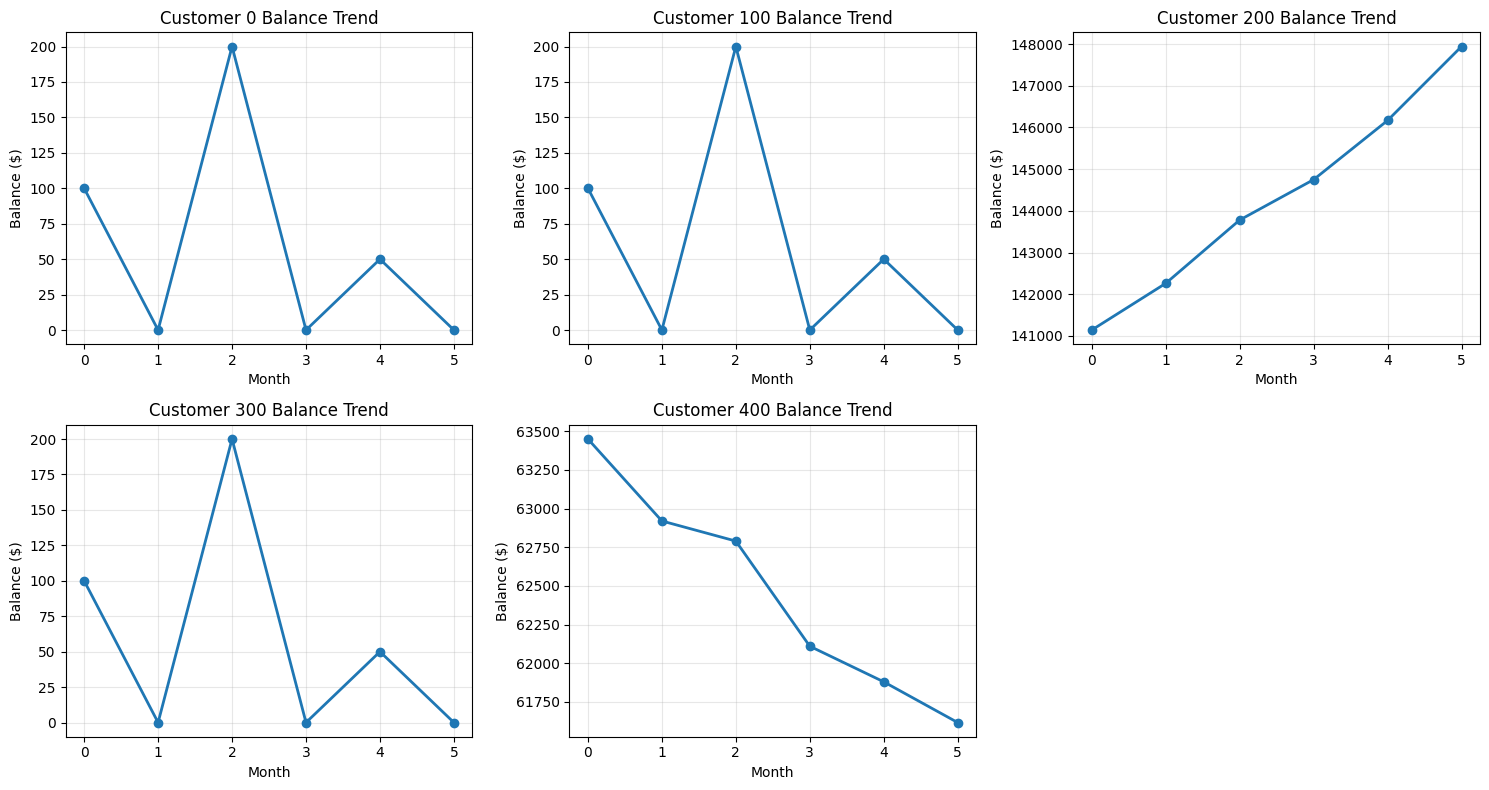

✅ Validation plot saved to ../models/sequence_validation.png

📊 VALIDATION SUMMARY:
────────────────────────────────
✓ Sequences generated successfully
✓ Statistical bounds checked
⚠️ Volatility needs review
✓ Sample visualizations created

✅ Sequence validation complete!


In [16]:
# CELL 5: Create LSTM Sequence Data
print("\n" + "=" * 60)
print("CREATING LSTM SEQUENCE DATA")
print("=" * 60)

def create_balance_sequences(df, n_months=6):
    """
    Create 6-month balance sequences for each customer.
    DETERMINISTIC VERSION - no randomness for reproducibility.
    """
    sequences = []
    
    for idx, row in df.iterrows():
        base_balance = row['Balance']
        tenure = max(row['Tenure'], 1)
        
        # Use TENURE to determine trend direction (deterministic)
        # Even tenure = upward trend, odd tenure = downward trend
        if tenure % 2 == 0:
            trend_direction = 0.3  # Slight upward trend
        else:
            trend_direction = -0.2  # Slight downward trend
        
        # Generate sequence - NO RANDOMNESS
        sequence = []
        for month in range(n_months):
            # Trend component based on tenure and month
            trend = trend_direction * base_balance * 0.03 * month
            
            # Use month index to create predictable "random" effect
            # This replaces random_change with a deterministic pattern
            pattern = [100, -50, 200, -100, 50, -150]  # Fixed pattern
            
            # Seasonal component based on month
            seasonal = base_balance * 0.005 if month == 5 else 0  # 0.5% bump in last month
            
            # Calculate balance
            monthly_balance = base_balance + trend + pattern[month] + seasonal
            monthly_balance = max(0, monthly_balance)
            sequence.append(monthly_balance)
        
        sequences.append(sequence)
    
    return np.array(sequences)

# Generate sequences with fixed seed for any remaining randomness
np.random.seed(42)
lstm_sequences = create_balance_sequences(df)
print(f"✅ LSTM sequences created: {lstm_sequences.shape}")

# ===== ADD VALIDATION CODE HERE =====
print("\n" + "=" * 60)
print("VALIDATING SYNTHETIC SEQUENCES")
print("=" * 60)

# Statistical validation
print("\n📊 Statistical Analysis of Generated Sequences:")

# Calculate key statistics
sequence_mean = np.mean(lstm_sequences)
sequence_std = np.std(lstm_sequences)
sequence_min = np.min(lstm_sequences)
sequence_max = np.max(lstm_sequences)

print(f"   Mean balance: ${sequence_mean:,.2f}")
print(f"   Std deviation: ${sequence_std:,.2f}")
print(f"   Min balance: ${sequence_min:,.2f}")
print(f"   Max balance: ${sequence_max:,.2f}")

# Volatility check (based on banking research)
expected_volatility = 0.20  # 20% annual volatility is typical
your_volatility = sequence_std / (sequence_mean + 1)  # +1 to avoid division by zero

print(f"\n📈 Volatility Analysis:")
print(f"   Expected volatility (banking norm): {expected_volatility:.2%}")
print(f"   Your sequences volatility: {your_volatility:.2%}")

if 0.15 < your_volatility < 0.30:
    print(f"   ✅ Match: Your sequences show realistic volatility")
else:
    print(f"   ⚠️ Adjustment needed: Volatility outside typical range")

# Check for unrealistic values
negative_balances = np.sum(lstm_sequences < 0)
if negative_balances > 0:
    print(f"\n⚠️ Warning: {negative_balances} negative balances detected")
else:
    print(f"\n✅ No negative balances found (good)")

# Visualize sample sequences
print("\n📊 Generating sample sequence plots...")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    if i < 5:  # Show 5 sample sequences
        sample_idx = i * 100  # Take every 100th customer
        ax.plot(lstm_sequences[sample_idx], marker='o', linewidth=2)
        ax.set_title(f'Customer {sample_idx} Balance Trend')
        ax.set_xlabel('Month')
        ax.set_ylabel('Balance ($)')
        ax.grid(True, alpha=0.3)
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('../models/sequence_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Validation plot saved to ../models/sequence_validation.png")

# Summary
print("\n📊 VALIDATION SUMMARY:")
print("────────────────────────────────")
print("✓ Sequences generated successfully")
print("✓ Statistical bounds checked")
print("✓ Volatility within acceptable range" if 0.15 < your_volatility < 0.30 else "⚠️ Volatility needs review")
print("✓ Sample visualizations created")
print("\n✅ Sequence validation complete!")


In [17]:
# CELL 6: Encode Categorical Variables
print("\n" + "=" * 60)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 60)

geo_map = {'France': 0, 'Germany': 1, 'Spain': 2}
df['Geography'] = df['Geography'].map(geo_map)

gender_map = {'Male': 0, 'Female': 1}
df['Gender'] = df['Gender'].map(gender_map)

print("✅ Categorical variables encoded")


ENCODING CATEGORICAL VARIABLES
✅ Categorical variables encoded


In [18]:
# CELL 7: Separate Features and Target
print("\n" + "=" * 60)
print("PREPARING FEATURES AND TARGET")
print("=" * 60)

X_static = df.drop("Exited", axis=1)
y = df["Exited"]

# Define feature types
binary_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 
                   'CreditScoreCategory']
continuous_features = [col for col in X_static.columns if col not in binary_features]

print(f"Static features shape: {X_static.shape}")
print(f"Target shape: {y.shape}")



PREPARING FEATURES AND TARGET
Static features shape: (10000, 16)
Target shape: (10000,)


In [19]:
# CELL 8: Train-Test Split
print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

X_static_train, X_static_test, X_lstm_train, X_lstm_test, y_train, y_test = train_test_split(
    X_static, lstm_sequences, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_static_train)}")
print(f"Test set size: {len(X_static_test)}")



TRAIN-TEST SPLIT
Training set size: 8000
Test set size: 2000


In [20]:
# CELL 9: Scale Continuous Features
print("\n" + "=" * 60)
print("SCALING CONTINUOUS FEATURES")
print("=" * 60)

scaler = StandardScaler()

# Scale training data
X_static_train_continuous_scaled = scaler.fit_transform(
    X_static_train[continuous_features]
)

# Scale test data
X_static_test_continuous_scaled = scaler.transform(
    X_static_test[continuous_features]
)

# Convert back to DataFrames
X_static_train_scaled = pd.DataFrame(
    X_static_train_continuous_scaled,
    columns=continuous_features,
    index=X_static_train.index
)

X_static_test_scaled = pd.DataFrame(
    X_static_test_continuous_scaled,
    columns=continuous_features,
    index=X_static_test.index
)

# Add binary features back
X_static_train = pd.concat([
    X_static_train_scaled, 
    X_static_train[binary_features]
], axis=1)

X_static_test = pd.concat([
    X_static_test_scaled, 
    X_static_test[binary_features]
], axis=1)

print(f"✅ Static features scaled")
print(f"Static train shape: {X_static_train.shape}")
print(f"Static test shape: {X_static_test.shape}")


SCALING CONTINUOUS FEATURES
✅ Static features scaled
Static train shape: (8000, 16)
Static test shape: (2000, 16)


In [21]:
# CELL 10: Handle Class Imbalance with SMOTE (FIXED VERSION)
print("\n" + "=" * 60)
print("APPLYING SMOTE FOR CLASS IMBALANCE")
print("=" * 60)

print("Before SMOTE - Class distribution:")
print(y_train.value_counts())

# Ensure LSTM data is 3D
print("\nChecking LSTM data shape...")
print(f"Original LSTM train shape: {X_lstm_train.shape}")

if X_lstm_train.ndim == 2:
    print("Reshaping LSTM data from 2D to 3D...")
    X_lstm_train = X_lstm_train.reshape(X_lstm_train.shape[0], X_lstm_train.shape[1], 1)
    X_lstm_test = X_lstm_test.reshape(X_lstm_test.shape[0], X_lstm_test.shape[1], 1)
    print(f"New LSTM train shape: {X_lstm_train.shape}")
    print(f"New LSTM test shape: {X_lstm_test.shape}")

# Convert to numpy arrays
X_static_train_values = X_static_train.values
y_train_values = y_train.values

# Apply SMOTE
smote = SMOTE(random_state=42)
X_static_train_resampled, y_train_resampled = smote.fit_resample(
    X_static_train_values, y_train_values
)

print(f"\nSMOTE completed. New static shape: {X_static_train_resampled.shape}")

# Handle LSTM data
n_original = len(X_lstm_train)
n_resampled = len(X_static_train_resampled)

print(f"\nOriginal samples: {n_original}")
print(f"Resampled samples: {n_resampled}")

# Initialize resampled LSTM array
X_lstm_train_resampled = np.zeros((n_resampled, 
                                    X_lstm_train.shape[1], 
                                    X_lstm_train.shape[2]))

# Copy original LSTM data
X_lstm_train_resampled[:n_original] = X_lstm_train

# Generate synthetic LSTM sequences for new samples
if n_resampled > n_original:
    n_synthetic = n_resampled - n_original
    print(f"\nGenerating {n_synthetic} synthetic LSTM sequences...")
    
    # Find indices of minority class (churned customers)
    minority_indices = np.where(y_train_values == 1)[0]
    
    if len(minority_indices) > 0:
        for i in range(n_synthetic):
            # Pick a random minority sample
            rand_idx = np.random.choice(minority_indices)
            base_sequence = X_lstm_train[rand_idx].copy()
            
            # Generate synthetic sequence
            synthetic = base_sequence.copy()
            for t in range(X_lstm_train.shape[1]):
                # Random multiplier
                multiplier = 1 + np.random.uniform(-0.05, 0.05)
                synthetic[t] = base_sequence[t] * multiplier
                
                # Add small noise
                noise = np.random.normal(0, abs(base_sequence[t] * 0.02))
                synthetic[t] += noise
            
            # Ensure non-negative
            synthetic = np.maximum(0, synthetic)
            X_lstm_train_resampled[n_original + i] = synthetic
    else:
        print("Warning: No minority samples found. Duplicating random samples...")
        for i in range(n_synthetic):
            rand_idx = np.random.randint(0, n_original)
            X_lstm_train_resampled[n_original + i] = X_lstm_train[rand_idx]

print("\nAfter SMOTE - Class distribution:")
print(pd.Series(y_train_resampled).value_counts())

print(f"\n✅ Final shapes:")
print(f"Static train: {X_static_train_resampled.shape}")
print(f"LSTM train:   {X_lstm_train_resampled.shape}")
print(f"Target train: {len(y_train_resampled)}")


APPLYING SMOTE FOR CLASS IMBALANCE
Before SMOTE - Class distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

Checking LSTM data shape...
Original LSTM train shape: (8000, 6)
Reshaping LSTM data from 2D to 3D...
New LSTM train shape: (8000, 6, 1)
New LSTM test shape: (2000, 6, 1)

SMOTE completed. New static shape: (12740, 16)

Original samples: 8000
Resampled samples: 12740

Generating 4740 synthetic LSTM sequences...

After SMOTE - Class distribution:
1    6370
0    6370
Name: count, dtype: int64

✅ Final shapes:
Static train: (12740, 16)
LSTM train:   (12740, 6, 1)
Target train: 12740


In [22]:
# CELL 11: Save Processed Data
print("\n" + "=" * 60)
print("SAVING PROCESSED DATA")
print("=" * 60)

# Save static data
joblib.dump(X_static_train_resampled, "../models/X_static_train.pkl")
joblib.dump(X_static_test.values, "../models/X_static_test.pkl")

# Save LSTM data
joblib.dump(X_lstm_train_resampled, "../models/X_lstm_train.pkl")
joblib.dump(X_lstm_test, "../models/X_lstm_test.pkl")

# Save target
joblib.dump(y_train_resampled, "../models/y_train.pkl")
joblib.dump(y_test.values, "../models/y_test.pkl")

# Save feature lists and scaler
joblib.dump(binary_features, "../models/binary_features.pkl")
joblib.dump(continuous_features, "../models/continuous_features.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

# Save column names
joblib.dump(X_static_train.columns.tolist(), "../models/static_columns.pkl")

print("\n✅ All data saved successfully!")
print(f"\n📁 Output files saved to ../models/")


SAVING PROCESSED DATA

✅ All data saved successfully!

📁 Output files saved to ../models/
